### Individual Homework

#### Enter your name here: Wenndy Tatiana Benavides Duarte

In [5]:
%pip install pandas numpy matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
  Using cached pandas-2.3.3-cp39-cp39-macosx_11_0_arm64.whl (10.8 MB)
  Using cached numpy-2.0.2-cp39-cp39-macosx_14_0_arm64.whl (5.3 MB)
  Using cached matplotlib-3.9.4-cp39-cp39-macosx_11_0_arm64.whl (7.8 MB)
  Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
  Using cached pytz-2026.3.post1-py2.py3-none-any.whl (508 kB)
  Using cached tzdata-2026.4-py2.py3-none-any.whl (347 kB)
  Using cached kiwisolver-1.4.7-cp39-cp39-macosx_11_0_arm64.whl (64 kB)
  Using cached fonttools-4.60.2-cp39-cp39-macosx_10_9_universal2.whl (2.9 MB)
  Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
  Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
  Using cached importlib_resources-6.5.2-py3-none-any.whl (37 kB)
  Using cached pillow-11.3.0-cp39-cp39-macosx_11_0_arm64.whl (4.7 MB)
  Using cached contourpy-1.3.0-cp39-cp39-macosx_11_0_arm64.whl (249 kB)
You should consider upgrading via the '/Library/Developer/Comma

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Analysis of movies IMDB dataset**

We will look at a ***subset*** sample of movies, taken from the [Kaggle IMDB 5000 movie dataset](https://www.kaggle.com/carolzhangdc/imdb-5000-movie-dataset)

In [8]:
movies = pd.read_csv('../Data/movies.csv')
movies

,title,genre,director,year,duration,gross,budget,cast_facebook_likes,votes,reviews,rating
0,Avatar,Action,James Cameron,2009,178,760505847,237000000,4834,886204,3777,7.9
1,Titanic,Drama,James Cameron,1997,194,658672302,200000000,45223,793059,2843,7.7
2,Jurassic World,Action,Colin Trevorrow,2015,124,652177271,150000000,8458,418214,1934,7.0
3,The Avengers,Action,Joss Whedon,2012,173,623279547,220000000,87697,995415,2425,8.1
4,The Dark Knight,Action,Christopher Nolan,2008,152,533316061,185000000,57802,1676169,5312,9.0
...,...,...,...,...,...,...,...,...,...,...,...
2956,Locker 13,Thriller,Bruce Dellis,2014,95,2468,300000,2048,241,15,4.8
2957,The Ghastly Love of Johnny X,Comedy,Paul Bunnell,2012,106,2436,2000000,1611,344,113,5.7
2958,Detention of the Dead,Comedy,Alex Craig Mann,2012,87,1332,500000,2251,2038,49,4.6
2959,The Trials of Darryl Hunt,Crime,Ricki Stern,2006,106,1111,200000,2,771,21,7.7


Besides the obvious variables of `title`, `genre`, `director`, `year`, and `duration`, the rest of the variables are as follows:

-   `gross` : The gross earnings in the US box office, not adjusted for inflation
-   `budget`: The movie's budget
-   `cast_facebook_likes`: the number of facebook likes cast memebrs received
-   `votes`: the number of people who voted for (or rated) the movie in IMDB
-   `reviews`: the number of reviews for that movie
-   `rating`: IMDB average rating

**Produce a table with the count of movies by genre, ranked in descending order**


In [9]:
movies_by_genre = (movies
.groupby('genre')
.agg(
        number_movies = ('title', 'count')
    )
.sort_values('number_movies', ascending=False)
)

movies_by_genre

,number_movies
genre,
Comedy,848
Action,738
Drama,498
Adventure,288
Crime,202
Biography,135
Horror,131
Animation,35
Fantasy,28


**Produce a table with the average gross earning and budget (`gross` and `budget`) by genre. Calculate a variable `return_on_budget` which shows how many \$ did a movie make at the box office for each \$ of its budget. Ranked genres by this `return_on_budget` in descending order**

In [11]:
earnings_budget_by_genre = (
    movies
    .assign(
            return_on_budget = movies['gross'] / movies['budget']
            )
    .groupby('genre')
    .agg(
        gross_earnings=('gross', 'mean'),
        budget_earnings=('budget', 'mean'),
        return_on_budget=('return_on_budget', 'mean')
    )
    .sort_values('return_on_budget', ascending=False)
)

earnings_budget_by_genre


,gross_earnings,budget_earnings,return_on_budget
genre,,,
Horror,3.771374e+07,1.350492e+07,88.304785
Biography,4.520181e+07,2.854370e+07,22.280597
Musical,9.208400e+07,3.189500e+06,18.817819
Family,1.491605e+08,1.483333e+07,14.076490
Documentary,1.735397e+07,5.887852e+06,8.698550
Western,2.082188e+07,3.465000e+06,7.062800
Fantasy,4.240884e+07,1.758214e+07,6.681969
Animation,9.843379e+07,6.170143e+07,5.009095
Comedy,4.263055e+07,2.444632e+07,3.713990


**Produce a table that shows the top 15 directors who have created the highest gross revenue in the box office. Don't just show the total gross amount, but also the mean, median, and standard deviation per director**

In [12]:
top_15_directors = (
    movies
    .groupby('director')
        .agg(
            gross_revenue=('gross', 'sum'),
            avg_revenue=('gross', 'mean'),
            median_revenue=('gross', 'median'),
            std_revenue=('gross', 'std')
        )
        .sort_values('gross_revenue', ascending=False)
        .head(15)
)

top_15_directors

,gross_revenue,avg_revenue,median_revenue,std_revenue
director,,,,
Steven Spielberg,4014061704,1.745244e+08,164435221.0,1.014211e+08
Michael Bay,2231242537,1.716340e+08,138396624.0,1.271616e+08
Tim Burton,2071275480,1.294547e+08,76519172.0,1.087269e+08
Sam Raimi,2014600898,2.014601e+08,234903076.0,1.621266e+08
James Cameron,1909725910,3.182877e+08,175562880.5,3.091713e+08
Christopher Nolan,1813227576,2.266534e+08,196667606.5,1.872241e+08
George Lucas,1741418480,3.482837e+08,380262555.0,1.461939e+08
Robert Zemeckis,1619309108,1.245622e+08,100853835.0,9.130028e+07
Clint Eastwood,1378321100,7.254322e+07,46700000.0,7.548741e+07


**Produce a table that describes how ratings are distributed by genre. We don't want just the mean, but also, min, max, median, SD and some kind of a histogram or density graph that visually shows how ratings are distributed.**

,avg_rating,min_rating,max_rating,median_reting,std_rating
genre,,,,,
Action,6.232249,2.1,9.0,6.30,1.030362
Adventure,6.506597,2.3,8.6,6.60,1.093881
Animation,6.651429,4.5,8.0,6.90,0.968131
Biography,7.114074,4.5,8.9,7.20,0.759827
Comedy,6.109670,1.9,8.8,6.20,1.023075
Crime,6.915347,4.8,9.3,6.90,0.849356
Documentary,6.660000,1.6,8.5,7.40,1.766588
Drama,6.731526,2.1,8.8,6.80,0.916993
Family,6.500000,5.7,7.9,5.90,1.216553


Text(0, 0.5, 'Genre')

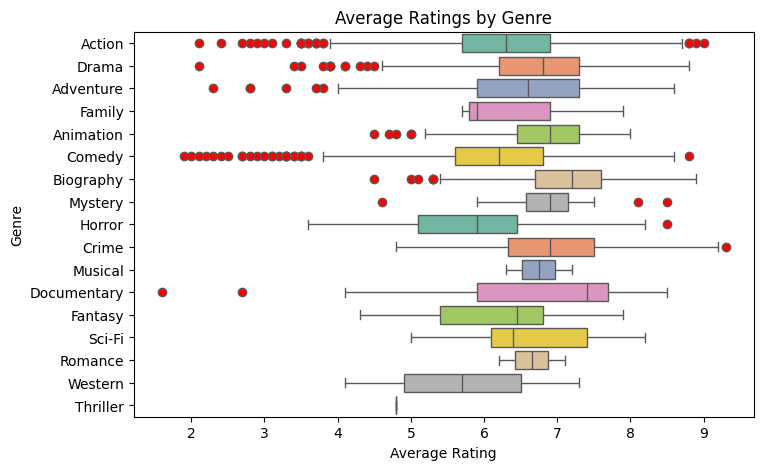

In [31]:
ratings_by_genre = (
    movies
    .groupby('genre')
        .agg(
            avg_rating=('rating', 'mean'),
            min_rating=('rating', 'min'),
            max_rating=('rating', 'max'),
            median_reting=('rating', 'median'),
            std_rating=('rating', 'std')
            
        )
)

display(ratings_by_genre)

plt.figure(figsize = (8,5))

sns.boxplot(
    data = movies,
    x = 'rating',
    y = 'genre',
    hue='genre',
    palette='Set2',
    flierprops={'markerfacecolor': 'red'}
)

plt.title('Average Ratings by Genre')
plt.xlabel('Average Rating')
plt.ylabel('Genre')

**Challenge - Produce a table of your own choosing, something you think is important/interesting to have data for, justify your result by writting a 2 sentence explanation/interpretation of the result.**

In [90]:
movies['duration_range'] = np.select(
    [
        movies['duration'] < 90,
        movies['duration'].between(90, 120),
        movies['duration'].between(121, 150),
        movies['duration'] > 150
    ],
    ['Less than 90 min', '90-120 min', '121-150 min', 'More than 150 min'],
    default='Unknown'
 )

duration_order = [
    'Less than 90 min',
    '90-120 min',
    '121-150 min',
    'More than 150 min',
    'Unknown'
 ]

movies['duration_range'] = pd.Categorical(
    movies['duration_range'],
    categories=duration_order,
    ordered=True
 )

movies_duration_ranges = (
    movies
    .groupby('duration_range')
    .agg(
        number_movies=('title', 'count'),
        average_rating=('rating', 'mean'),
        std_rating=('rating', 'std')
    )
 )

movies_duration_ranges

/var/folders/x9/_n30ryps0z38brvrtph2tjph0000gn/T/ipykernel_27112/1501217214.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  movies


,number_movies,average_rating,std_rating
duration_range,,,
Less than 90 min,349,5.850430,1.192689
90-120 min,1925,6.260260,0.979098
121-150 min,563,6.917052,0.848377
More than 150 min,124,7.511290,0.822766
Unknown,0,NaN,NaN


### **Explanation**
Longer movies receive higher average ratings, going from 5.85 for films under 90 minutes to 7.51 for those over 150 minutes. In addition, as the duration increases the standard deviation decreases, showing more consistent quality. However, this may reflect selection bias, as extended-runtime films represent a small sample (124 movies)

#### Use visualisation to answer the following questions

**Examine the relationship between `gross` and `cast_facebook_likes`. Produce a scatterplot and write one sentence discussing whether the number of facebook likes that the cast has received is likely to be a good predictor of how much money a movie will make at the box office. What variable are you going to map to the Y- and X- axes?**

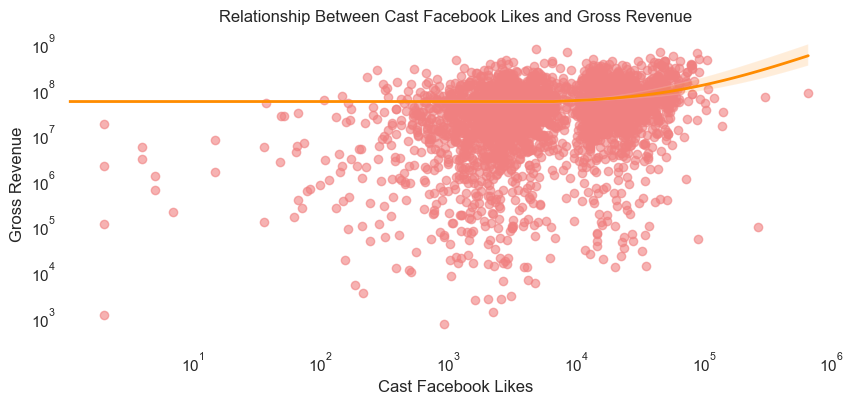

In [74]:
plt.figure(figsize=(10, 4), facecolor='white')

sns.regplot(
    data=movies,
    x='cast_facebook_likes',
    y='gross',
    scatter_kws={'color': 'lightcoral', 'alpha': 0.6},
    line_kws={'color': 'darkorange', 'linewidth': 2}
 )

plt.xscale('log')
plt.yscale('log')

ax = plt.gca()
ax.set_facecolor('white')

plt.title('Relationship Between Cast Facebook Likes and Gross Revenue')
plt.xlabel('Cast Facebook Likes')
plt.ylabel('Gross Revenue')
plt.show()

### **Explanation**
Although an increase in *cast facebook likes* is accompanied by a very slight rise in *gross revenue*, the high number of outliers makes *likes* a weak predictor of gross revenue

**Examine the relationship between `gross` and `budget`. Produce a scatterplot and write one sentence discussing whether budget is likely to be a good predictor of how much money a movie will make at the box office.**

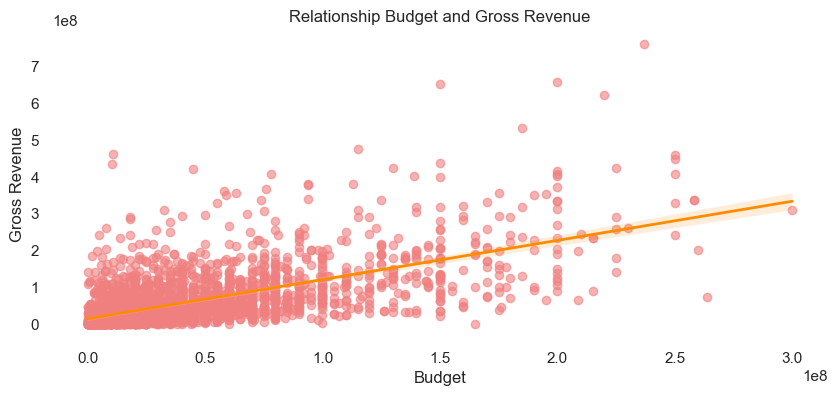

In [81]:
plt.figure(figsize=(10, 4), facecolor='white')

sns.regplot(
    data=movies,
    x='budget',
    y='gross',
    scatter_kws={'color': 'lightcoral', 'alpha': 0.6},
    line_kws={'color': 'darkorange', 'linewidth': 2}
 )

#plt.xscale('log')
#plt.yscale('log')

ax = plt.gca()
ax.set_facecolor('white')

plt.title('Relationship Budget and Gross Revenue')
plt.xlabel('Budget')
plt.ylabel('Gross Revenue')
plt.show()

### **Explanation**
As the *budget* increases, there is a positive trend in *gross revenue*. However, volatility also increases, leading to a wider margin of error in predictions

**Examine the relationship between `gross` and `rating`. Produce a scatterplot, faceted by `genre` and discuss whether IMDB ratings are likely to be a good predictor of how much money a movie will make at the box office. Is there anything strange in this dataset?**

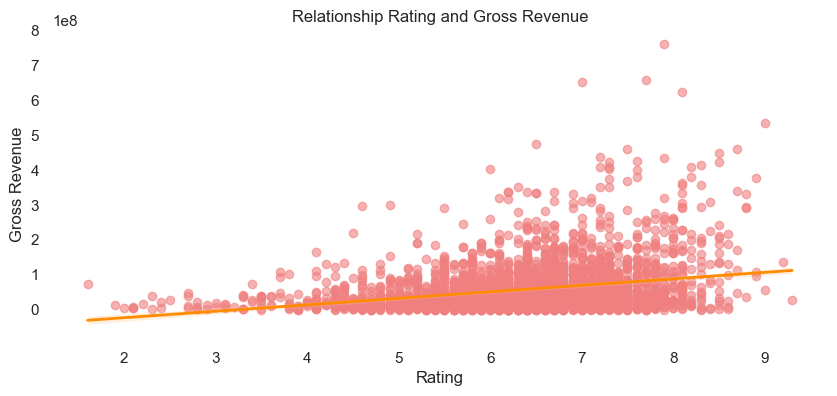

In [80]:
plt.figure(figsize=(10, 4), facecolor='white')

sns.regplot(
    data=movies,
    x='rating',
    y='gross',
    scatter_kws={'color': 'lightcoral', 'alpha': 0.6},
    line_kws={'color': 'darkorange', 'linewidth': 2}
 )


ax = plt.gca()
ax.set_facecolor('white')

plt.title('Relationship Rating and Gross Revenue')
plt.xlabel('Rating')
plt.ylabel('Gross Revenue')
plt.show()

### **Explanation**
while low-rated films consistently generate low revenue, high-rated films exhibit a wide spread, making rating a weak standalone predictor of gross revenue

**Challenge - Produce a visualisation of your choosing, something you think is important to explore/investigate visually. Do make it a comprehensive graph and not a single histogram or density plot. Make it publication ready, label your axes, give it a title, choose colouring options, appropirately formatted text etc.**

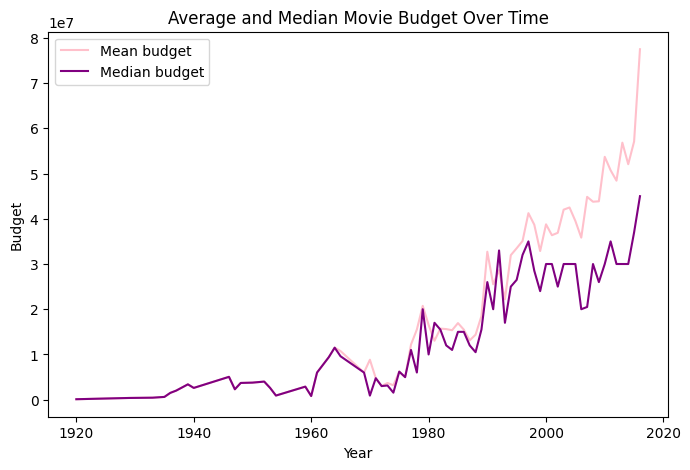

In [56]:
budget_over_years = (
    movies.groupby('year')
    .agg(
        avg_budget=('budget', 'mean'),
        median_budget=('budget', 'median')
    )
    .reset_index()
)

plt.figure(figsize=(8, 5))

sns.lineplot(
    data=budget_over_years,
    x='year',
    y='avg_budget',
    color='pink',
    label='Mean budget'
)

sns.lineplot(
    data=budget_over_years,
    x='year',
    y='median_budget',
    color='purple',
    label='Median budget'
)

plt.title('Average and Median Movie Budget Over Time')
plt.xlabel('Year')
plt.ylabel('Budget')
plt.legend()
plt.show()

### **Explanation**
The *Average and Median Movie Budget Over Time* graph shows an increase over the years, which is likely related to inflation. However, as the median moves away from the mean, it is possible to hypothesize that budget growth is driven not only by inflation, but also by extreme outliers within the movie industry

### Deliverables

Poduce a clean, stand-alone notebook (or HTML export) with:

All tables/plots properly labeled

Brief interpretations where requested

Upload final HTML/Notebook.